<a href="https://colab.research.google.com/github/Kevin-gram/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hate Speech analysis: Analysis and Model creation

## 1. Data analysis and preprocessing:
In this step we examine the dataset we have at hand. By examining the dataset we have we can then take various steps to create the best model or suggest a different solution

Imports necessary libraries like pandas, scikit-learn, nltk, re, matplotlib, and seaborn for data manipulation, model building, text processing, and visualization.

In [1]:
# importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re
import matplotlib.pyplot as plt
import seaborn as sns

Loads the dataset from a CSV file named 'hate.csv' using pandas and displays its shape (number of rows and columns).

In [2]:
# Load the dataset
dataset = pd.read_csv('hate.csv', encoding='latin-1')
dataset.shape

(41144, 3)

 Shows the first few rows of the dataset using head().

In [3]:
dataset.head()

,Unnamed: 0,comment,label
0,1,dalits are lowlives,N
1,2,gay people are a burden to our society,N
2,3,Arabs are not welcome,N
3,4,I'm not saying we should actually eliminate he...,N
4,5,bananas are for black people,N


Displays the last few rows of the dataset using tail().

In [ ]:
dataset.tail()

,Unnamed: 0,comment,label
41139,117100,Indian culture is so backwards,N
41140,118100,"Women don't want equality, they just want to b...",N
41141,119100,fuck covid,P
41142,1205,This computer is garbage,P
41143,121100,The only good Muslim is a dead one,N


Provides information about the dataset, including column names, data types, and non-null values, using info()

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41144 entries, 0 to 41143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  41144 non-null  int64 
 1   comment     41144 non-null  object
 2   label       41144 non-null  object
dtypes: int64(1), object(2)
memory usage: 964.4+ KB


Shows descriptive statistics of the dataset using describe(), including count, mean, standard deviation, etc.

In [ ]:
# check statistical measures
dataset.describe(include = 'all')

,Unnamed: 0,comment,label
count,41144.000000,41144,41144
unique,NaN,41134,3
top,NaN,Blacks are such pondlife,N
freq,NaN,5,22158
mean,20703.991056,NaN,NaN
std,12580.884040,NaN,NaN
min,1.000000,NaN,NaN
25%,10295.750000,NaN,NaN
50%,20593.500000,NaN,NaN
75%,30894.250000,NaN,NaN


Checks for missing values (null values) in each column using isnull().sum().

In [ ]:
# check for null values
dataset.isnull().sum()

,0
Unnamed: 0,0
comment,0
label,0


***No further action since we have no null values***

Counts the number of unique values in each column using nunique().

In [ ]:
# check unique values
dataset.nunique()

,0
Unnamed: 0,41144
comment,41134
label,3


Specifically counts the unique values in the 'label' column.

In [ ]:
dataset.nunique()['label']

3

Shows the frequency of each unique value in the 'label' column using value_counts().

In [ ]:
dataset.value_counts('label')

,count
label,
N,22158
P,18950
O,36


Creates a bar plot to visualize the distribution of the 'label' column.

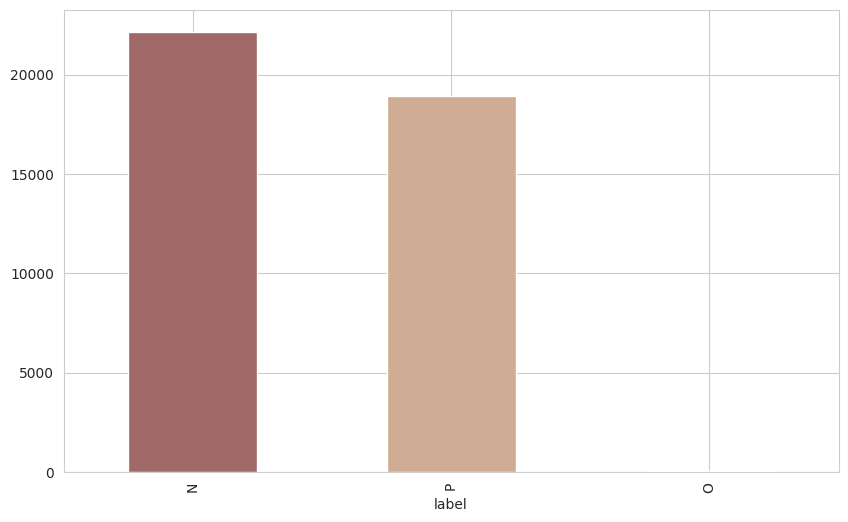

In [ ]:
# Define figure size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot with better aesthetics
ax = dataset['label'].value_counts().plot(kind='bar', color=sns.color_palette("pink", len(dataset['label'].unique())))


 Shows the frequency of each unique value in the 'comment' column.

In [ ]:
dataset.value_counts('comment')

,count
comment,
Blacks are such pondlife,5
Muslims are a disgrace,3
Politicians are crap,2
Politicians are scum,2
I endorse the genocide of Muslims,2
...,...
Illegal Immigrant could be charged With Raping Incapacitated Woman In Kentucky. Shouldn't be released on bail,1
"Illegal Immigrant could be charged With Raping Incapacitated Woman In Kentucky. Shouldn't be released on bail, rightly so, as they probably took 'no' was 'yes' as their women are like slaves to them.",1
Illegal alien invaders* sounds more like it,1


Downloads necessary resources for NLTK (Natural Language Toolkit), including 'punkt' and 'stopwords'.

In [3]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

 Defines a function called preprocess_text to clean and prepare text data. This includes converting to lowercase, removing special characters, tokenization, removing stop words, and lemmatization instead of stemming. It then applies this function to the 'comment' column and stores the results in a new column called 'preprocessed_tex

 ***Why lemmatization over stemming?***
 lemmatization though slightly slower mantains the meanings and legitimacy of most of the words unlike stemming which will sometimes after cutting suffixes leave us with unreal words.

 We also used synonym replacement and random deletion to increase variance between hateful and non-hateful comments in our dataset

In [4]:
import nltk
import re
import random
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

def synonym_replacement(text, n=2):
    """Replace up to 'n' words with synonyms from WordNet."""
    words = text.split()
    new_words = words[:]

    for _ in range(n):
        word_idx = random.randint(0, len(words) - 1)
        synonyms = wordnet.synsets(words[word_idx])
        if synonyms:
            new_words[word_idx] = random.choice(synonyms[0].lemma_names())

    return ' '.join(new_words)

def random_deletion(text, p=0.2):
    """Randomly delete words with probability p."""
    words = text.split()
    if len(words) == 1: return text  # Avoid empty strings
    new_words = [word for word in words if random.uniform(0, 1) > p]
    return ' '.join(new_words) if new_words else words[0]

def preprocess_text(text, augment=True):
    """Preprocess text with optional augmentation."""
    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers (keep hashtags and mentions)
    text = re.sub(r'[^a-zA-Z\s#@]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization (instead of stemming)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Handle empty strings
    if not tokens:
        return 'empty'

    # Join tokens back into text
    preprocessed_text = ' '.join(tokens)

    # Apply Augmentations if enabled
    if augment:
        if random.random() < 0.5:  # 50% chance to apply synonym replacement
            preprocessed_text = synonym_replacement(preprocessed_text, 2)
        if random.random() < 0.5:  # 50% chance to apply random deletion
            preprocessed_text = random_deletion(preprocessed_text, 0.2)

    return preprocessed_text

# Apply preprocessing to the dataset
dataset['preprocessed_text'] = dataset['comment'].apply(lambda x: preprocess_text(x, augment=True))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


We can add a wordcloud to visualize the most common words in the whole dataset. This will allow ass to have an idea of what's the most dominant class in the datase

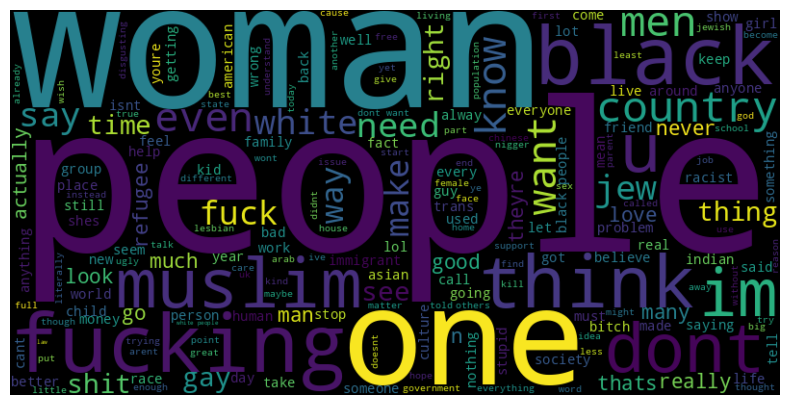

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all preprocessed text into a single string
text_corpus = ' '.join(dataset['preprocessed_text'])

# Generate WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='viridis'
).generate(text_corpus)

# Display the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.show()


Prints the shapes (number of rows and columns) of the training and testing sets (X_train, X_test, y_train, y_test).

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(dataset['preprocessed_text'], dataset['label'], test_size=0.2, random_state=42)


Prints the shapes (number of rows and columns) of the training and testing sets (X_train, X_test, y_train, y_test).

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(32915,)
(8229,)
(32915,)
(8229,)


### BERT-Based Text Classification
This notebook initializes a BERT tokenizer and model for sequence classification with three possible labels, leveraging the transformers library. This model will allow as to later compare transformers models(which w already know are better) and the models we built

In [6]:

from transformers import BertTokenizer, BertForSequenceClassification, AdamW
import torch

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 2. **Text Classification with Support Vector Machine (SVM) using TF-IDF Vectorization**

**Explanation:**
In this step, a Support Vector Machine (SVM) with a linear kernel is used for the text classification task. The model pipeline includes TF-IDF vectorization to transform text data into numerical features, followed by training an SVM classifier. After training the model on the training data, predictions are made on the test set. The performance is evaluated using accuracy and a detailed classification report, which includes precision, recall, and F1-score, providing insights into the model's classification capabilities.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define the pipeline with TF-IDF, normalization, and early stopping
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into TF-IDF vectors
    ('scaler', MaxAbsScaler()),  # Normalize features while keeping data sparse
    ('sgd', SGDClassifier(loss='hinge',  # Similar to SVM (hinge loss)
                          max_iter=1000,  # Maximum iterations
                          tol=1e-3,  # Stop when improvement is below threshold
                          early_stopping=False,  # Enables early stopping
                          validation_fraction=0.1,  # 10% of training used for validation
                          n_iter_no_change=5,  # Stop if no improvement in 5 epochs
                          random_state=42))  # Ensure reproducibility
])

# Train the model with early stopping
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


Accuracy: 0.632276096731073
Classification Report:
               precision    recall  f1-score   support

           N       0.64      0.69      0.67      4375
           O       0.00      0.00      0.00         4
           P       0.62      0.57      0.59      3850

    accuracy                           0.63      8229
   macro avg       0.42      0.42      0.42      8229
weighted avg       0.63      0.63      0.63      8229



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.compose import ColumnTransformer

# Define the pipeline with scaling
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('scaler', MaxAbsScaler()),  # Scale the TF-IDF features
    ('svm', SVC(kernel='linear'))
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


Accuracy: 0.6226759022967554
Classification Report:
               precision    recall  f1-score   support

           N       0.64      0.68      0.66      4375
           O       0.00      0.00      0.00         4
           P       0.61      0.56      0.58      3850

    accuracy                           0.62      8229
   macro avg       0.41      0.41      0.41      8229
weighted avg       0.62      0.62      0.62      8229



In [ ]:
# Model selection and training
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Define the model pipeline
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC(kernel='linear'))
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.6692186170859157
Classification Report:
               precision    recall  f1-score   support

           N       0.68      0.71      0.69      4375
           O       0.00      0.00      0.00         4
           P       0.65      0.63      0.64      3850

    accuracy                           0.67      8229
   macro avg       0.45      0.44      0.44      8229
weighted avg       0.67      0.67      0.67      8229



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Compute classification performance metrics: accuracy, precision, recall, and F1-score
**Evaluating the Model Performance with Key Metrics**

**Explanation:**
In this step, the performance of the trained model is evaluated using several key metrics: accuracy, precision, recall, and F1-score. These metrics provide a comprehensive assessment of how well the model predicts the test set, with a focus on both overall accuracy and the balance between precision and recall. The weighted average is used to account for class imbalances, providing a more robust evaluation when dealing with multi-class classification tasks.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# y_pred contains the predicted labels and y_test contains the true labels
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.6692186170859157
Precision: 0.6683366966789801
Recall: 0.6692186170859157
F1-score: 0.6685305167246044


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Train and evaluate a Random Forest model using TF-IDF features
**Text Classification with Random Forest Classifier using TF-IDF Vectorization**

**Explanation:**
In this step, a Random Forest Classifier is applied to the text classification task, with TF-IDF vectorization used to convert text data into numerical features. The model is trained on the training data and predictions are made on the test set. The model's performance is evaluated using accuracy and a detailed classification report, which provides insights into the model's precision, recall, and other performance metrics. This allows for a thorough evaluation of how well the Random Forest model performs compared to the Logistic Regression model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the model pipeline with Random Forest classifier
model_pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('rf', RandomForestClassifier())
])

# Train the model
model_pipeline_rf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = model_pipeline_rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.6692186170859157
Classification Report:
               precision    recall  f1-score   support

           N       0.68      0.71      0.69      4375
           O       0.00      0.00      0.00         4
           P       0.65      0.63      0.64      3850

    accuracy                           0.67      8229
   macro avg       0.45      0.44      0.44      8229
weighted avg       0.67      0.67      0.67      8229



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Text Classification with Logistic Regression using TF-IDF Vectorization**


In this step, we build a text classification model by applying Logistic Regression in combination with TF-IDF vectorization to transform the text data into numerical features. The model is trained on the training dataset, followed by predictions on the test set. The performance of the model is then evaluated using several metrics: accuracy, precision, recall, F1 score, and a detailed classification report. These evaluations help assess the model's effectiveness and identify areas for improvement.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define the model pipeline with Logistic Regression
model_pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression())
])

# Train the model
model_pipeline_lr.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = model_pipeline_lr.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_score_lr = f1_score(y_test, y_pred_lr, average='weighted')
classification_report_lr = classification_report(y_test, y_pred_lr)

# Print evaluation metrics
print("Evaluation Metrics for Logistic Regression Model:")
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_score_lr)
print("\nClassification Report:")
print(classification_report_lr)

Evaluation Metrics for Logistic Regression Model:
Accuracy: 0.6671527524608093
Precision: 0.6661690324837957
Recall: 0.6671527524608093
F1 Score: 0.6661824269462965

Classification Report:
              precision    recall  f1-score   support

           N       0.68      0.71      0.69      4375
           O       0.00      0.00      0.00         4
           P       0.65      0.62      0.63      3850

    accuracy                           0.67      8229
   macro avg       0.44      0.44      0.44      8229
weighted avg       0.67      0.67      0.67      8229



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

## 3. Deep Learning model
In this section we develop a deep learning model to perform our task of hate speech classification. In this section we'll tweak the model to squeeze better performance out of each iteration by changing feature engineering methods and other parameters. We chose an LSTM model which by default uses a tanh activation function. We'll also use BERT for word embeddings as mentioned earlier.

Using the initialized tokenizer we can start the encoding process

In [7]:
# Tokenize and pad sequences using BERT
def encode_texts(texts, tokenizer, max_len):
    encoding = tokenizer(texts.tolist(), padding='max_length', truncation=True, max_length=max_len, return_tensors='tf')
    return encoding['input_ids'], encoding['attention_mask']

We then initialize varibles like max len which gives the model the idea of the allowed sentence maximum length. We also perform some label encoding for the classes we are working with. We also add paddings to our texts.

In [8]:
# tokenize, pad, convert and encode sequences

from sklearn.preprocessing import LabelEncoder
import numpy as np

max_len = 200
vocab_size = tokenizer.vocab_size
X_train_pad, _ = encode_texts(X_train, tokenizer, max_len)
X_test_pad, _ = encode_texts(X_test, tokenizer, max_len)

# Convert to numpy arrays from PyTorch tensors
X_train_pad = X_train_pad.numpy()
X_test_pad = X_test_pad.numpy()

# Encode string labels to integers
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print(X_train_pad.shape)
print(X_test_pad.shape)
print(y_train_enc.shape)
print(y_test_enc.shape)


(32915, 200)
(8229, 200)
(32915,)
(8229,)


Model architecture creation. We start witha a simple LSTM no dropout layers to see what we can

### Model 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=768, input_length=max_len),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(len(set(y_train)), activation='softmax')
])

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

history = model.fit(X_train_pad, y_train_enc, epochs=5, batch_size=32, validation_data=(X_test_pad, y_test_enc))


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1029/1029 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - accuracy: 0.5267 - loss: 0.7064 - val_accuracy: 0.5317 - val_loss: 0.6952
Epoch 2/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.5359 - loss: 0.6989 - val_accuracy: 0.5317 - val_loss: 0.6952
Epoch 3/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.5335 - loss: 0.6983 - val_accuracy: 0.5317 - val_loss: 0.6952
Epoch 4/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.5358 - loss: 0.6982 - val_accuracy: 0.5317 - val_loss: 0.6955
Epoch 5/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.5386 - loss: 0.6981 - val_accuracy: 0.5317 - val_loss: 0.6957


Error analysis to have a sense of how our model performed

258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69      4375
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00      3850

    accuracy                           0.53      8229
   macro avg       0.18      0.33      0.23      8229
weighted avg       0.28      0.53      0.37      8229

LSTM Model Accuracy: 0.5316563373435411
LSTM Model F1 Score: 0.3690886188317982
LSTM Model Precision: 0.2826584610375492
LSTM Model Recall: 0.5316563373435411
Confusion Matrix:
 [[4375    0    0]
 [   4    0    0]
 [3850    0    0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

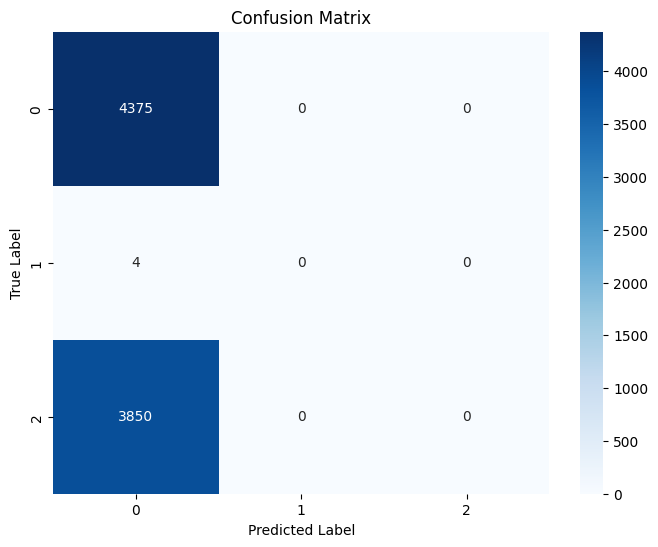

In [ ]:
# Evaluating the model
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

y_pred = model.predict(X_test_pad)
y_pred_labels = np.argmax(y_pred, axis=1)

report = classification_report(y_test_enc, y_pred_labels)
accuracy = accuracy_score(y_test_enc, y_pred_labels)
f1_score = f1_score(y_test_enc, y_pred_labels, average='weighted')
precision = precision_score(y_test_enc, y_pred_labels, average='weighted')
recall = recall_score(y_test_enc, y_pred_labels, average='weighted')
confusion = confusion_matrix(y_test_enc, y_pred_labels)

print("Classification Report:\n", report)
print("LSTM Model Accuracy:", accuracy)
print("LSTM Model F1 Score:", f1_score)
print("LSTM Model Precision:", precision)
print("LSTM Model Recall:", recall)
print("Confusion Matrix:\n", confusion)

# plotting the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(len(set(y_train))),
            yticklabels=range(len(set(y_train))))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

***Model 1 deduction:***
From what we can see The classification report and confusion matrix indicate a severe class imbalance in the dataset. The model predicts almost exclusively the majority class (label **0**) i.e hate comments, achieving **100% recall** for it but completely failing to classify the other two classes (**1 and 2**)neutral and non-hateful. This results in **zero precision, recall, and F1-score** for the minority classes, meaning the model does not recognize any instances of hate speech (if labels **1 and 2** represent such cases). The accuracy of **53.17%** is misleading because it is simply due to the majority class dominating the dataset. To improve performance, we are going to add better optimization techniques in the following models

### Model 1.2:model 1 but With Regularization, dropout layers and early stopping

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define LSTM model
model11 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=768, input_length=max_len),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(len(set(y_train)), activation='softmax')
])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Compile the model
model11.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

history = model11.fit(X_train_pad, y_train_enc, epochs=10, batch_size=64, validation_data=(X_test_pad, y_test_enc), callbacks=[early_stopping])


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.5256 - loss: 0.8078 - val_accuracy: 0.4679 - val_loss: 0.7038
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5174 - loss: 0.7075 - val_accuracy: 0.5317 - val_loss: 0.6967
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.5251 - loss: 0.7035 - val_accuracy: 0.5317 - val_loss: 0.6954
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.5312 - loss: 0.6999 - val_accuracy: 0.5317 - val_loss: 0.6952
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.5280 - loss: 0.6997 - val_accuracy: 0.5317 - val_loss: 0.6953
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.5426 - loss: 0.6968 - val_accuracy: 0.5317 - val_loss: 0.6951
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.5317 - loss: 0.6999 - val_accuracy: 0.5317 - val_loss: 0.6951
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.5361 - loss: 0.6970 - val_accurac

258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Classification Report:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69      4375
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00      3850

    accuracy                           0.53      8229
   macro avg       0.18      0.33      0.23      8229
weighted avg       0.28      0.53      0.37      8229

LSTM Model 1.2 Accuracy: 0.5316563373435411
LSTM Model 1.2 F1 Score: 0.3690886188317982
LSTM Model 1.2 Precision: 0.2826584610375492
LSTM Model 1.2 Recall: 0.5316563373435411
Confusion Matrix:
 [[4375    0    0]
 [   4    0    0]
 [3850    0    0]]


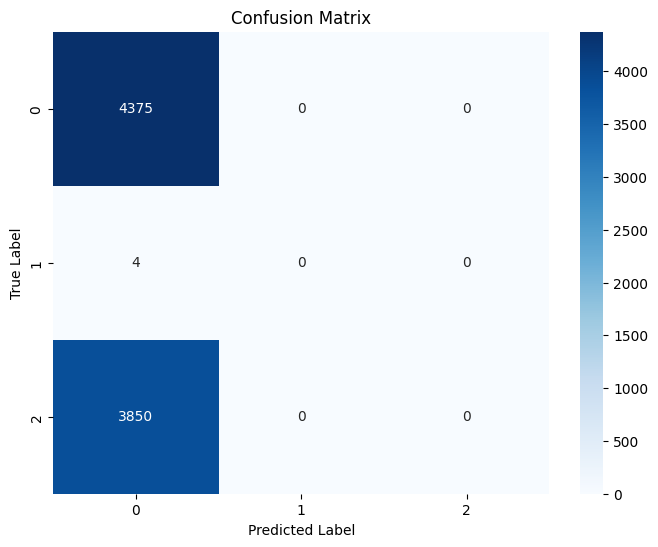

In [10]:
# Evaluating the model
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

y_pred = model11.predict(X_test_pad)
y_pred_labels = np.argmax(y_pred, axis=1)

report = classification_report(y_test_enc, y_pred_labels)
accuracy = accuracy_score(y_test_enc, y_pred_labels)
f1_score = f1_score(y_test_enc, y_pred_labels, average='weighted')
precision = precision_score(y_test_enc, y_pred_labels, average='weighted')
recall = recall_score(y_test_enc, y_pred_labels, average='weighted')
confusion = confusion_matrix(y_test_enc, y_pred_labels)

print("Classification Report:\n", report)
print("LSTM Model 1.2 Accuracy:", accuracy)
print("LSTM Model 1.2 F1 Score:", f1_score)
print("LSTM Model 1.2 Precision:", precision)
print("LSTM Model 1.2 Recall:", recall)
print("Confusion Matrix:\n", confusion)

# plotting the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(len(set(y_train))),
            yticklabels=range(len(set(y_train))))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

***Model 1.2 conclusion:*** Obviously this refined model did not solve much of our issues. We are going to tweak our word embedding method to see if there's improvement

### Model 2.1: Word2Vev embedding
In this model we are going to tweak our method of word embedding and see if maybe this model can outperform the previous model.

In [ ]:
import numpy as np
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

# Prepare Text Data for Word2Vec
sentences = [text.split() for text in X_train]  # Tokenize text into words

# Train Word2Vec Model
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Create Tokenizer and Convert Texts to Sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for padding token

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

# Encode Labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Create Embedding Matrix
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

# Define LSTM Model
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(len(set(y_train)), activation='softmax')
])

# Compile Model
model2.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

# Train Model
history = model2.fit(X_train_pad, y_train_enc, epochs=10, batch_size=64, validation_data=(X_test_pad, y_test_enc))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.5247 - loss: 0.7206 - val_accuracy: 0.5317 - val_loss: 0.6954
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - accuracy: 0.5329 - loss: 0.7013 - val_accuracy: 0.5317 - val_loss: 0.6960
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.5346 - loss: 0.6996 - val_accuracy: 0.5317 - val_loss: 0.6969
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.5388 - loss: 0.6991 - val_accuracy: 0.5317 - val_loss: 0.6979
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5391 - loss: 0.6993 - val_accuracy: 0.5317 - val_loss: 0.6978
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.5392 - loss: 0.6990 - val_accuracy: 0.5317 - val_loss: 0.6975
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.5393 - loss: 0.6986 - val_accuracy: 0.5317 - val_loss: 0.6978
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.5394 - loss: 0.6987 - val_accurac

258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Classification Report:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69      4375
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00      3850

    accuracy                           0.53      8229
   macro avg       0.18      0.33      0.23      8229
weighted avg       0.28      0.53      0.37      8229

LSTM v2 Model Accuracy: 0.5316563373435411
LSTM v2 Model F1 Score: 0.3690886188317982
LSTM v2 Model Precision: 0.2826584610375492
LSTM v2 Model Recall: 0.5316563373435411
Confusion Matrix:
 [[4375    0    0]
 [   4    0    0]
 [3850    0    0]]


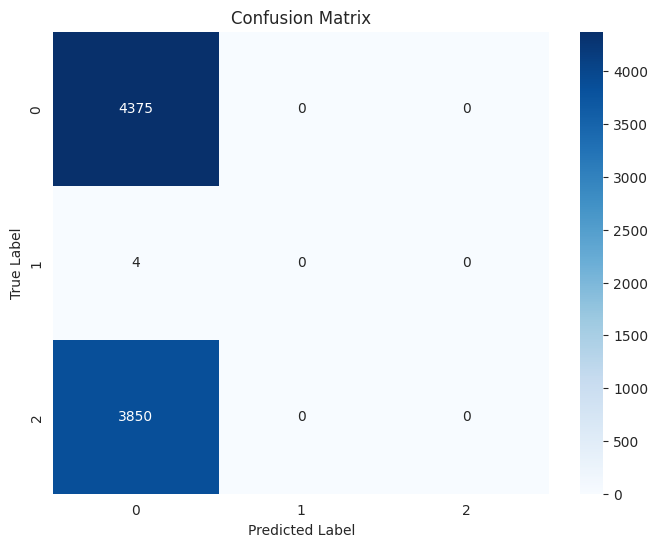

In [ ]:
# Evaluating the model
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

y_pred = model2.predict(X_test_pad)
y_pred_labels = np.argmax(y_pred, axis=1)

report2 = classification_report(y_test_enc, y_pred_labels)
accuracy2 = accuracy_score(y_test_enc, y_pred_labels)
f1_score2 = f1_score(y_test_enc, y_pred_labels, average='weighted')
precision2 = precision_score(y_test_enc, y_pred_labels, average='weighted')
recall2 = recall_score(y_test_enc, y_pred_labels, average='weighted')
confusion2 = confusion_matrix(y_test_enc, y_pred_labels)

print("Classification Report:\n", report2)
print("LSTM v2 Model Accuracy:", accuracy2)
print("LSTM v2 Model F1 Score:", f1_score2)
print("LSTM v2 Model Precision:", precision2)
print("LSTM v2 Model Recall:", recall2)
print("Confusion Matrix:\n", confusion2)

# plotting the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion2, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(len(set(y_train))),
            yticklabels=range(len(set(y_train))))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

***Model 2.1 conclusion***: There is so much similarity between this confusion matrix with the one in the previous problem. This means our model is neither doing well on both word encoding method modification nor doing well when parameters are fine-tuned. This shows either an underlying issue with our process or the dataset. I would point my fingers to the latter for the following reasons:

- **The dataset is quite unbalanced**: The classes are very unbalanced as the instances of neutral comments are ten thousand times less than that of the hateful comments which is why the model is performing really well on the hateful comment class

_ **The complexity of the dataset**: Opening the dataset out team couldn't even tell apart most of the hateful and non-hateful comments. This makes the dataset quite complex for a normal LSTM i presume. We would recommend using an advanced method like using a transformers model(out of scope of our assignment) which will definetely outperform any model we created in this assignment.


**Authors**:
- Mbuto Davy(SVM, Linear model creation, word embedding)
- Kevin Nyiringango(Data preprocessing and analysis)
- Ken Ganza(Deep Learning and further analysis)
